# Fitting GMM using EM algorithm

Dataset: 

$$
\mathcal{D} = \{x\}_N
$$



In [33]:
import numpy as np

np.random.seed(42)
cluster_1 = np.random.normal(loc=[2, 2], scale=[0.5, 0.5], size=(150, 2))
cluster_2 = np.random.normal(loc=[7, 7], scale=[1.0, 1.0], size=(150, 2))
cluster_3 = np.random.normal(loc=[2, 7], scale=[0.5, 0.5], size=(150, 2))

X_train = np.vstack([cluster_1, cluster_2, cluster_3])

print("Points:", X_train[:3])

Points: [[2.24835708 1.93086785]
 [2.32384427 2.76151493]
 [1.88292331 1.88293152]]


Model:

$$
p(x) = \sum_k \pi_k \mathcal N(x\mid \mu_k, \Sigma_k)
$$

In [34]:
from dataclasses import dataclass

@dataclass
class GMM:
    K: int
    def initialize_parameters(self, X):
        self.N, self.D = X.shape
        self.pi = np.ones(self.K) / self.K
        random_indices = np.random.choice(self.N, self.K, replace=False)
        self.mu = X[random_indices]
        self.sigma = np.array([np.eye(self.D) for _ in range(self.K)])

model = GMM(K=2)
model.initialize_parameters(X_train)
print("Priors:", model.pi)
print("Means:\n", model.mu)
print("Covariances:\n", model.sigma)

Priors: [0.5 0.5]
Means:
 [[1.68759071 7.01304553]
 [2.25751763 2.25689298]]
Covariances:
 [[[1. 0.]
  [0. 1.]]

 [[1. 0.]
  [0. 1.]]]


# E-step

Computation of responsibility of each Gaussian for each sample

$$
r_{kx} = p(k,x) = \frac{p(k)p(x\mid k)}{\sum_j^K p(j)p(x\mid j)} = \frac{\pi_k \mathcal N(x\mid \mu_k, \Sigma_k)}{\sum_j^K \pi_j \mathcal N(x\mid \mu_j, \Sigma_j)} 
$$


In [35]:
import numpy as np
from scipy.stats import multivariate_normal


def e_step(gmm, X):
    likelihoods = np.zeros((gmm.N, gmm.K))
    for k in range(gmm.K):
        distribution = multivariate_normal(mean=gmm.mu[k], cov=gmm.sigma[k], allow_singular=True)
        likelihoods[:, k] = distribution.pdf(X)
        
    weighted_likelihoods = likelihoods * gmm.pi
    sum_likelihoods = np.sum(weighted_likelihoods, axis=1)[:, np.newaxis]
    gamma = weighted_likelihoods / sum_likelihoods
    return gamma, np.sum(np.log(sum_likelihoods))

gamma, lln = e_step(model, X_train)
gamma[:3]

array([[2.21932272e-06, 9.99997781e-01],
       [1.10471310e-04, 9.99889529e-01],
       [2.17598223e-06, 9.99997824e-01]])

# M-step (GMM-specific)

Effective cluster point count
$$
N_k = \sum_{j=1}^N r_{kj}
$$

**Updates**:

priors

$$
\pi_k = \frac{N_k}{N}
$$

means

$$
\mu_k' = \frac{1}{N_k} \sum_{j=1}^N r_{kj} x_j
$$

and covariance

$$
\Sigma_k' = \frac{1}{N_k} \sum_{j=1}^N r_{kj} (x_j - \mu_k')^2
$$

# M-step derivation

Let $\theta = (\boldsymbol \pi, \boldsymbol \mu, \boldsymbol \Sigma)$. 
We minimize expected complete data log likelihood

$$
\mathcal{L}(\theta) = \sum_{x \in \mathcal{D}} \sum_{k=1}^K r_{kx} LL(x, k \mid \mu_k \Sigma_k) = \\
\sum_{x \in \mathcal{D}} \sum_{k=1}^K r_{kx} \operatorname{log} (\pi_k) + \sum_{x \in \mathcal{D}} \sum_{k=1}^K r_{kx} \operatorname{log}(\mathcal{N} (x \mid \mu_k, \Sigma_k))
$$

Priors: optimize using Lagrange multipliers (because $\boldsymbol \pi$ belongs to probability simplex).

$$
\mathcal{L}_\pi = \sum_{x \in \mathcal{D}} \sum_{k=1}^K r_{kx} \operatorname{log} (\pi_k) + \lambda (1 - \sum_{k=1}^K \pi_k) \\\\
\frac{\partial \mathcal{L}_\pi}{\partial \pi_k} = \frac{1}{\pi_k} \sum_{j=1}^N r_{kj} - \lambda = 0 \\
\rightarrow \pi_k = \frac{\sum_{j=1}^N r_{kj}}{\lambda} = \frac{N_k}{N}
$$

Means and covariances: just equal the derivatives to zero and find the updated parameter.

$$
\frac{\partial \mathcal{L}}{\partial \mu_k} = 0
$$
$$
\frac{\partial \mathcal{L}}{\partial \Sigma_k} = 0 
$$


In [36]:
def m_step(model, X, gamma):
    N_k = np.sum(gamma, axis=0)
    
    for k in range(model.K):
        model.pi[k] = N_k[k] / model.N
        model.mu[k] = (1 / N_k[k]) * np.sum(gamma[:, k][:, np.newaxis] * X, axis=0)
        diff = X - model.mu[k]
        model.sigma[k] = (1 / N_k[k]) * np.dot((gamma[:, k][:, np.newaxis] * diff).T, diff)
    return model

model = m_step(model, X_train, gamma=gamma)
print("Updated Priors:", model.pi)
print("Updated Means:\n", model.mu)
print("Updated Covariances:\n", model.sigma)

Updated Priors: [0.65460381 0.34539619]
Updated Means:
 [[4.46627934 7.0375056 ]
 [2.16389086 2.12336094]]
Updated Covariances:
 [[[ 6.82869986 -0.05464435]
  [-0.05464435  0.50738774]]

 [[ 1.15392286  0.55617488]
  [ 0.55617488  0.59376609]]]


# Full algorithm

In [ ]:
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from IPython.display import clear_output
import time

def plot_gmm_state(X, model, iteration, gamma=None):
    plt.figure(figsize=(8, 6))
    plt.gca().set_facecolor('#fbf1c7')
    plt.rcParams['figure.facecolor'] = '#fbf1c7'
    plt.rcParams['axes.facecolor'] = '#fbf1c7'
    plt.rcParams['text.color'] = '#3c3836'
    plt.rcParams['axes.labelcolor'] = '#3c3836'
    plt.rcParams['xtick.color'] = '#3c3836'
    plt.rcParams['ytick.color'] = '#3c3836'
    
    if gamma is not None and model.K == 2:
        colors = np.c_[gamma[:, 0], np.zeros_like(gamma[:, 0]), gamma[:, 1]]
        plt.scatter(X[:, 0], X[:, 1], c=colors, alpha=0.6, s=20)
    else:
        plt.scatter(X[:, 0], X[:, 1], color='gray', alpha=0.6, s=20)

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.mgrid[x_min:x_max:.05, y_min:y_max:.05]
    pos = np.dstack((xx, yy))

    for k in range(model.K):
        try:
            rv = multivariate_normal(mean=model.mu[k], cov=model.sigma[k])
            plt.contour(xx, yy, rv.pdf(pos), levels=4, alpha=0.5, linewidths=2)
            plt.scatter(model.mu[k, 0], model.mu[k, 1], 
                        marker='X', s=150, 
                        edgecolors='k', label=f'Mean {k}')
        except np.linalg.LinAlgError:
            pass

    plt.title(f"EM Algorithm - Iteration {iteration}")
    plt.legend()
    
    clear_output(wait=True)
    plt.show()
    time.sleep(0.5)

def fit_em(model: GMM):
    MAX_ITERS = 10
    TOL = 1e-5
    model.initialize_parameters(X_train)
    plot_gmm_state(X_train, model, iteration=0)

    lls = []
    for i in range(MAX_ITERS):
        gamma, ll = e_step(model, X_train)
        lls.append(ll)
        
        if i > 0 and np.abs(ll - lls[-1]) < TOL:
            print(f"Converged at iteration {i+1}")
            break
            
        m_step(model, X_train, gamma)
        plot_gmm_state(X_train, model, iteration=i+1, gamma=gamma)
    return model, lls

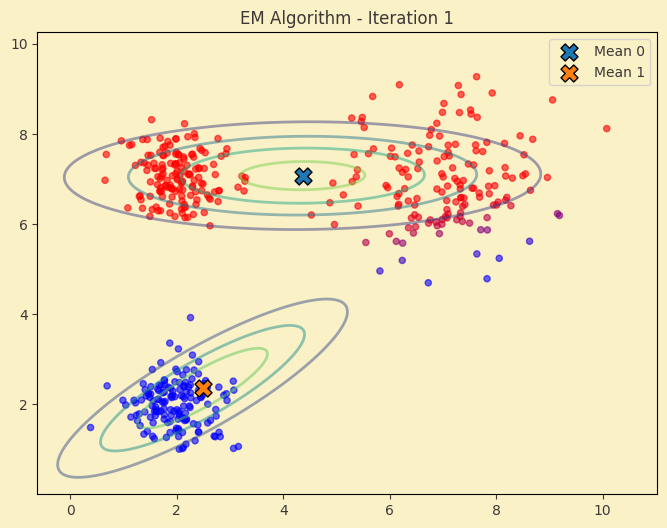

Converged at iteration 2


(GMM(K=2), [np.float64(-4108.03238796313), np.float64(-1694.4505417632865)])

In [48]:
fit_em(GMM(K=2))


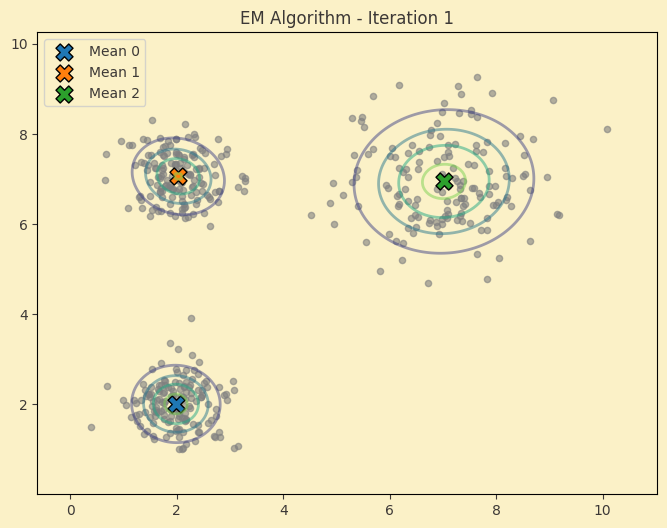

Converged at iteration 2


(GMM(K=3), [np.float64(-1612.8966012439412), np.float64(-1335.0606286645889)])

In [51]:
fit_em(GMM(K=3))